# **Monthly Milk Production Forecasting using RNN, LSTM, and GRU**

The Aim is to forecast monthly milk production using deep learning models like Basic RNN, LSTM, and GRU.The dairy business wants to forecast future milk production so that it can plan supply chain, storage, workforce, and production activities properly.

# **Importing  Required Libraries**

In [2]:
!pip install tensorflow
!pip install keras

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

# **Loading the Dataset**

In [5]:
df = pd.read_csv("/content/drive/MyDrive/ASSIGNMENTS/RNN/monthly_milk_production.csv")

In [6]:

df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


# **Exploring the Dataset**

In [8]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

Shape of dataset: (168, 2)

Column names:
Index(['Date', 'Production'], dtype='object')

Data types:
Date          object
Production     int64
dtype: object

Missing values:
Date          0
Production    0
dtype: int64

Basic statistics:
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


The dataset contains monthly milk production values. It has two columns: Date and Production. There are no missing values in the dataset, so no major missing value treatment is required.

# **Converting Date Column**

In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

df.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


Explanation:
The Date column is converted into datetime format for time series analysis.

# **Plotting Milk Production Trend**

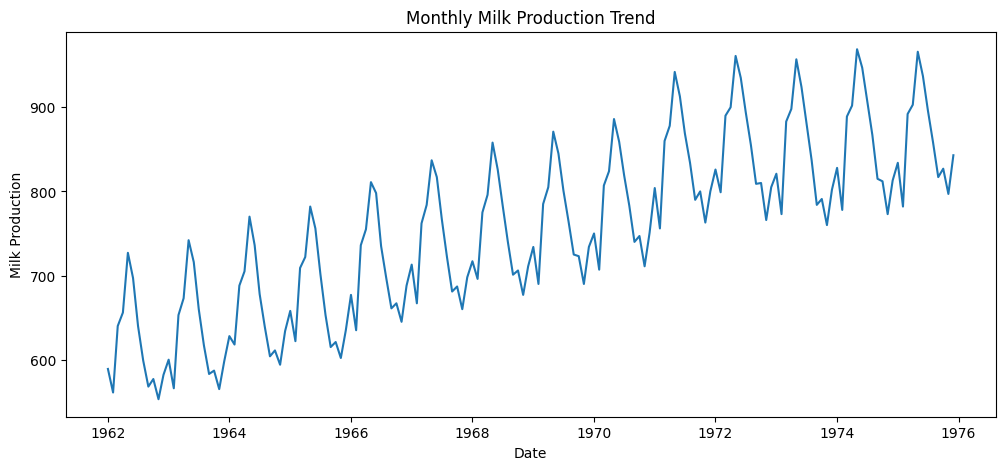

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Production"])
plt.title("Monthly Milk Production Trend")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.show()

Explanation:
This graph shows the overall trend in milk production over time.It helps us observe trend, seasonality, and fluctuations in production.

# **Checking the Seasonality by Month**

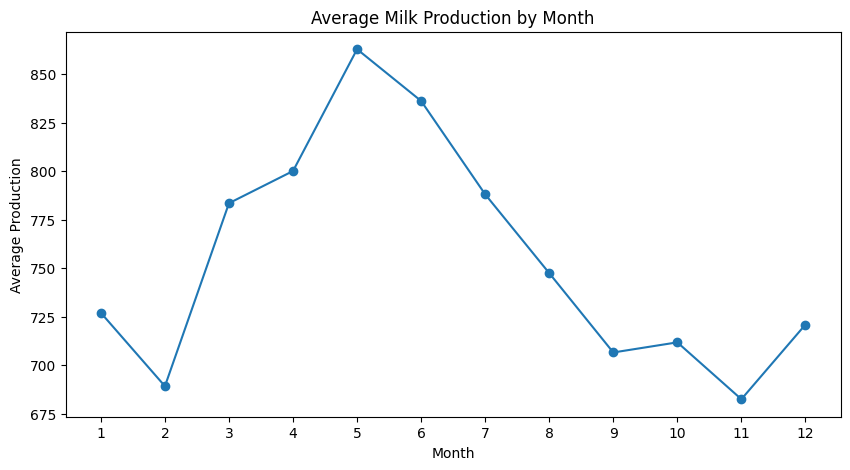

In [13]:
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

monthly_avg = df.groupby("Month")["Production"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.title("Average Milk Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))
plt.show()

This graph shows average milk production for each month. If some months have consistently high or low production, it indicates seasonality.

# **Checking Outliers**

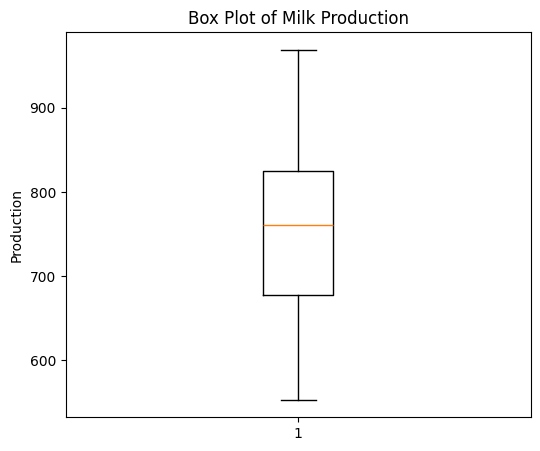

In [14]:
plt.figure(figsize=(6, 5))
plt.boxplot(df["Production"])
plt.title("Box Plot of Milk Production")
plt.ylabel("Production")
plt.show()

Explanation:
Box plot is used to check if there are any unusual production values.Outliers are values that are very different from normal production values.

# **Normalize the Data**

In [15]:
production_values = df[["Production"]].values

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(production_values)

print("Original first 5 values:")
print(production_values[:5])

print("\nScaled first 5 values:")
print(scaled_values[:5])

Original first 5 values:
[[589]
 [561]
 [640]
 [656]
 [727]]

Scaled first 5 values:
[[0.08653846]
 [0.01923077]
 [0.20913462]
 [0.24759615]
 [0.41826923]]


Explanation:
Neural network models work better when data is scaled. Here I scale production values between 0 and 1.Production values are normalized using MinMaxScaler. Scaling helps RNN, LSTM, and GRU models learn better because all values come into a similar range.

# **Create Time Window Sequences**

In [16]:
def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

window_size = 12

X, y = create_sequences(scaled_values, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


Explanation:
For time series forecasting, previous months are used to predict the next month. Here we use 12 months as input to predict the next month.A window size of 12 means the model uses the previous 12 months of milk production to predict the next month.

# **Train, Validation, and Test Split**

In [17]:
total_samples = len(X)

train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("Training shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Testing shape:", X_test.shape, y_test.shape)

Training shape: (109, 12, 1) (109, 1)
Validation shape: (23, 12, 1) (23, 1)
Testing shape: (24, 12, 1) (24, 1)


Explanation:
The data is split in time order because this is time series data. We should not shuffle time series data.Training data is used to train the model, validation data is used during training, and testing data is used for final evaluation.

# **Evaluation Function**

In [18]:
def calculate_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return rmse, mae, mape

Explanation:
This function calculates RMSE, MAE, and MAPE.

# **Model Building**

**Build Basic RNN Model**

In [19]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(50, activation="tanh", input_shape=(window_size, 1)))
rnn_model.add(Dense(1))

rnn_model.compile(optimizer="adam", loss="mse")

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Explanation:
Basic RNN is a simple recurrent neural network used for sequence data.

**Train Basic RNN Model**

In [20]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0851 - val_loss: 0.0735
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0169 - val_loss: 0.0089
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0079 - val_loss: 0.0247
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - val_loss: 0.0054
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0075
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - val_loss: 0.0050
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021 - val_loss: 0.0035
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 - val_loss: 0.0033
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0018 - val_loss: 0.0037
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 - val_loss: 0.0042
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0017 - val_

**Build LSTM Model**

In [21]:
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation="tanh", input_shape=(window_size, 1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Explanation:
LSTM is useful for time series data because it can remember long-term patterns better than a basic RNN.

**Train LSTM Model**

In [22]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0668 - val_loss: 0.0384
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0299 - val_loss: 0.0287
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0243 - val_loss: 0.0266
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0235 - val_loss: 0.0257
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0230 - val_loss: 0.0266
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0233 - val_loss: 0.0245
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0226 - val_loss: 0.0244
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0219 - val_loss: 0.0234
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0211 - val_loss: 0.0244
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0211 - val_loss: 0.0222


**Build GRU Model**

In [23]:
gru_model = Sequential()
gru_model.add(GRU(50, activation="tanh", input_shape=(window_size, 1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer="adam", loss="mse")

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

Explanation:
GRU is similar to LSTM but simpler and faster. It also works well for sequence forecasting.

**Train GRU Model**

In [24]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.1274 - val_loss: 0.0998
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0282 - val_loss: 0.0256
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0274 - val_loss: 0.0469
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0263 - val_loss: 0.0499
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0248 - val_loss: 0.0330
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0230 - val_loss: 0.0317
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0230 - val_loss: 0.0366
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0219 - val_loss: 0.0262
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0201 - val_loss: 0.0293
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0204 - val_loss: 0.0302


# **Model Evaluation**

Make Predictions

In [25]:
rnn_pred_scaled = rnn_model.predict(X_test)
lstm_pred_scaled = lstm_model.predict(X_test)
gru_pred_scaled = gru_model.predict(X_test)

# Convert scaled values back to original production values
y_test_actual = scaler.inverse_transform(y_test)

rnn_pred = scaler.inverse_transform(rnn_pred_scaled)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
gru_pred = scaler.inverse_transform(gru_pred_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step


**Calculate Metrics**

In [26]:
rnn_rmse, rnn_mae, rnn_mape = calculate_metrics(y_test_actual, rnn_pred)
lstm_rmse, lstm_mae, lstm_mape = calculate_metrics(y_test_actual, lstm_pred)
gru_rmse, gru_mae, gru_mape = calculate_metrics(y_test_actual, gru_pred)

results = pd.DataFrame({
    "Model": ["Basic RNN", "LSTM", "GRU"],
    "RMSE": [rnn_rmse, lstm_rmse, gru_rmse],
    "MAE": [rnn_mae, lstm_mae, gru_mae],
    "MAPE": [rnn_mape, lstm_mape, gru_mape]
})

results

,Model,RMSE,MAE,MAPE
0,Basic RNN,16.511154,13.767779,1.575811
1,LSTM,76.227297,65.235657,7.825285
2,GRU,138.231014,123.861816,13.990846


RMSE, MAE, and MAPE are used to evaluate forecasting performance. Lower values indicate better performance. The model with the lowest RMSE and MAE performs better.

# **Plot Actual vs Predicted Values**

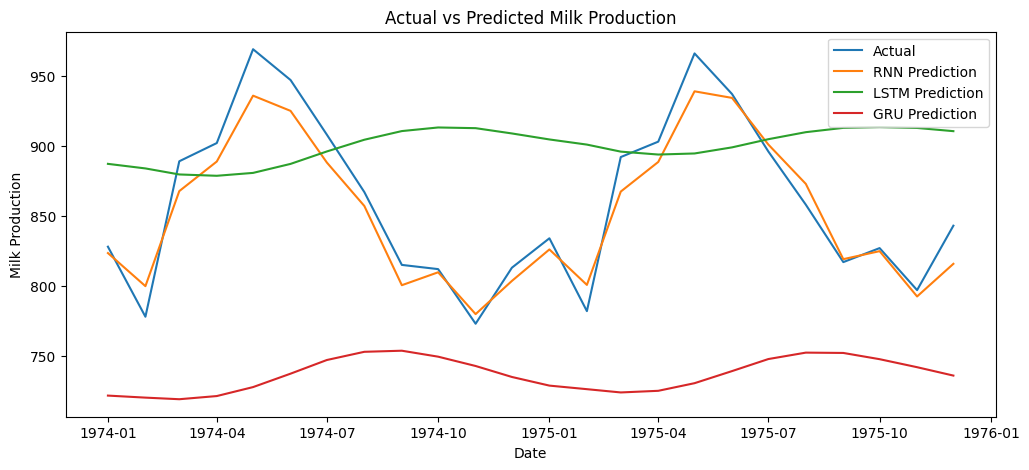

In [27]:
test_dates = df["Date"].iloc[-len(y_test_actual):]

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_actual, label="Actual")
plt.plot(test_dates, rnn_pred, label="RNN Prediction")
plt.plot(test_dates, lstm_pred, label="LSTM Prediction")
plt.plot(test_dates, gru_pred, label="GRU Prediction")

plt.title("Actual vs Predicted Milk Production")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

This graph compares actual milk production with predicted production from RNN, LSTM, and GRU models. The model whose line is closer to the actual line is better.

# **Compare Model Performance using Bar Chart**

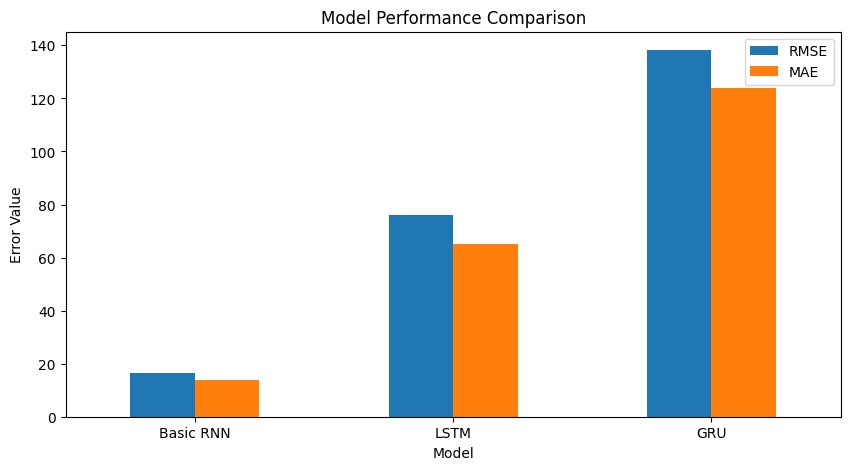

In [28]:
results.set_index("Model")[["RMSE", "MAE"]].plot(kind="bar", figsize=(10, 5))

plt.title("Model Performance Comparison")
plt.ylabel("Error Value")
plt.xticks(rotation=0)
plt.show()

This bar chart compares the error values of all three models. Lower bars show better model performance.

# **Forecast Next 12 Months**

**Select Best Model**

In [29]:
best_model_name = results.sort_values("RMSE").iloc[0]["Model"]

if best_model_name == "Basic RNN":
    best_model = rnn_model
elif best_model_name == "LSTM":
    best_model = lstm_model
else:
    best_model = gru_model

print("Best Model:", best_model_name)

Best Model: Basic RNN


**Forecast Future 12 Months**

In [30]:
future_predictions_scaled = []

last_window = scaled_values[-window_size:]
current_window = last_window.reshape(1, window_size, 1)

for i in range(12):
    next_pred = best_model.predict(current_window, verbose=0)
    future_predictions_scaled.append(next_pred[0][0])

    current_window = np.append(
        current_window[:, 1:, :],
        [[[next_pred[0][0]]]],
        axis=1
    )

future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
)

future_dates = pd.date_range(
    start=df["Date"].iloc[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Production": future_predictions.flatten()
})

future_df

,Date,Forecasted Production
0,1976-01-01,835.441223
1,1976-02-01,803.110168
2,1976-03-01,871.497009
3,1976-04-01,885.730042
4,1976-05-01,934.283142
5,1976-06-01,922.399841
6,1976-07-01,895.036316
7,1976-08-01,866.388245
8,1976-09-01,826.965820
9,1976-10-01,836.616699


**Visualize Future Forecast**

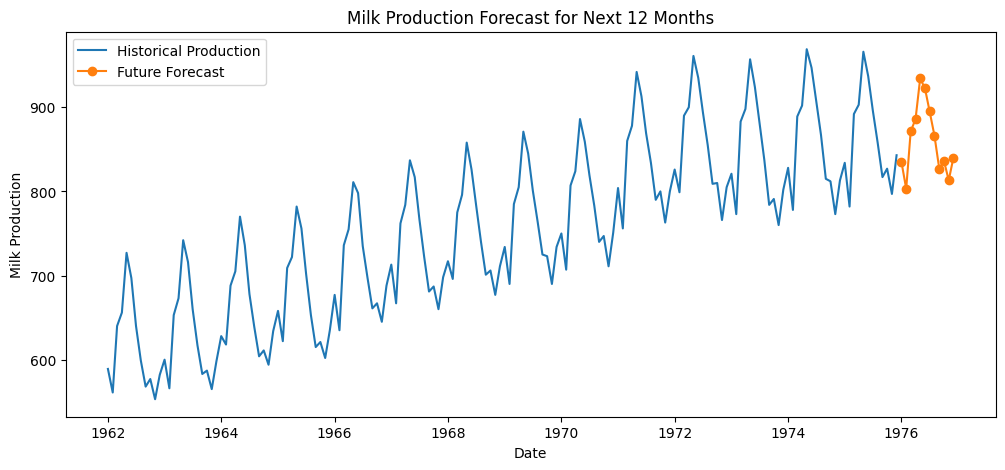

In [31]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Production"], label="Historical Production")
plt.plot(future_df["Date"], future_df["Forecasted Production"], marker="o", label="Future Forecast")

plt.title("Milk Production Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

This graph shows historical milk production and forecasted production for the next 12 months. It helps the business understand expected future production.

# **Forecast with Simple Confidence Range**

In [32]:
if best_model_name == "Basic RNN":
    best_test_pred = rnn_pred
elif best_model_name == "LSTM":
    best_test_pred = lstm_pred
else:
    best_test_pred = gru_pred

error_std = np.std(y_test_actual - best_test_pred)

future_df["Lower Range"] = future_df["Forecasted Production"] - 1.96 * error_std
future_df["Upper Range"] = future_df["Forecasted Production"] + 1.96 * error_std

future_df

,Date,Forecasted Production,Lower Range,Upper Range
0,1976-01-01,835.441223,807.121277,863.761169
1,1976-02-01,803.110168,774.790222,831.430115
2,1976-03-01,871.497009,843.177063,899.816956
3,1976-04-01,885.730042,857.410095,914.049988
4,1976-05-01,934.283142,905.963196,962.603088
5,1976-06-01,922.399841,894.079895,950.719788
6,1976-07-01,895.036316,866.716370,923.356262
7,1976-08-01,866.388245,838.068298,894.708191
8,1976-09-01,826.965820,798.645874,855.285767
9,1976-10-01,836.616699,808.296753,864.936646


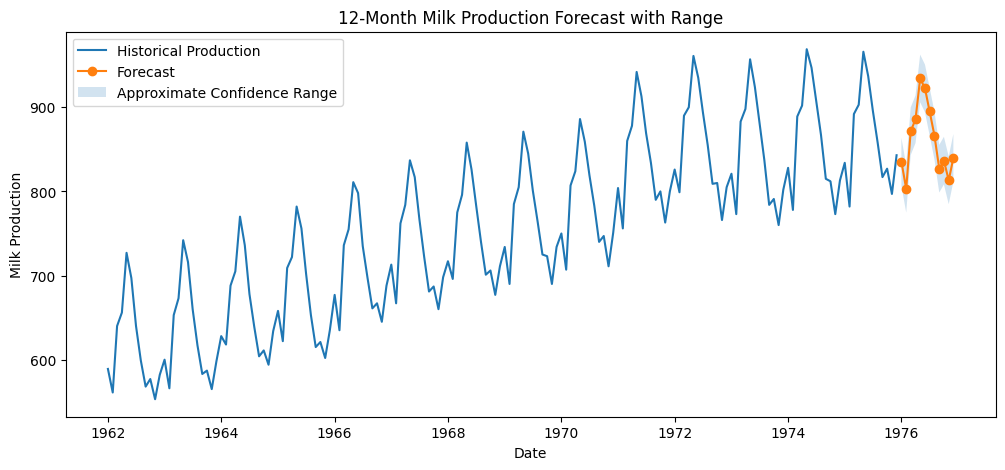

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(df["Date"], df["Production"], label="Historical Production")
plt.plot(future_df["Date"], future_df["Forecasted Production"], marker="o", label="Forecast")
plt.fill_between(
    future_df["Date"],
    future_df["Lower Range"],
    future_df["Upper Range"],
    alpha=0.2,
    label="Approximate Confidence Range"
)

plt.title("12-Month Milk Production Forecast with Range")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

This creates a simple upper and lower range using prediction error. It is not a perfect confidence interval, but it gives an approximate uncertainty range.

# **Final Analysis**

In this assignment, monthly milk production data was analyzed and forecasted using deep learning models. First, the dataset was loaded and explored. The Date column was converted into datetime format, and the Production column was used for forecasting.

EDA was performed using trend plots, monthly seasonality analysis, and box plots. The data was normalized using MinMaxScaler because neural network models perform better when values are scaled. After that, time-window sequences were created using the previous 12 months of production to predict the next month.

Three models were built: Basic RNN, LSTM, and GRU. These models were trained using training data and validated using validation data. After training, predictions were made on the test data. The models were evaluated using RMSE, MAE, and MAPE.

The model with the lowest RMSE was selected as the best model. Using that model, milk production for the next 12 months was forecasted. The final forecast helps understand future production trends.

# **Business Insights**

The dairy business can use this forecasting system for better planning and decision-making. If future milk production is expected to increase, the business can arrange more storage, transportation, and workforce in advance. If production is expected to decrease, the business can control inventory and avoid wastage.

The forecast can help in:
1. Supply chain planning
2. Inventory and storage management
3. Workforce planning
4. Production scheduling
5. Seasonal demand management
6. Reducing wastage
7. Better business decision-making

# **Conclusion**

RNN, LSTM, and GRU models were implemented for monthly milk production forecasting. The models were compared using RMSE, MAE, and MAPE. The best model was selected and used to forecast production for the next 12 months. This type of forecasting can help dairy businesses plan resources and operations more effectively.